# Google Merchandise Store Funnel Analysis

## Python Exploratory Data Analysis


### Import Libraries and Load Datasets

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
events = pd.read_csv(r"C:\Users\meghn\OneDrive\Desktop\Funnel Analytics Project Work\events_clean.csv")
items = pd.read_csv(r"C:\Users\meghn\OneDrive\Desktop\Funnel Analytics Project Work\items.csv")
users = pd.read_csv(r"C:\Users\meghn\OneDrive\Desktop\Funnel Analytics Project Work\users.csv")

### Dataset Overview and Initial Inspection


In [42]:
events.shape

(719386, 7)

In [13]:
items.shape

(1381, 6)

In [12]:
users.shape

(270154, 3)

In [43]:
events.head()

,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,01-11-2020 00:27
1,2133,16909,US,mobile,purchase,425,01-11-2020 00:27
2,5789,16908,SE,desktop,purchase,1,01-11-2020 01:44
3,5789,16908,SE,desktop,purchase,62,01-11-2020 01:44
4,5808,4267,US,mobile,add_to_cart,842,01-11-2020 03:06


In [44]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 719386 entries, 0 to 719385
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user_id        719386 non-null  int64
 1   ga_session_id  719386 non-null  int64
 2   country        719386 non-null  str  
 3   device         719386 non-null  str  
 4   type           719386 non-null  str  
 5   item_id        719386 non-null  int64
 6   date           719386 non-null  str  
dtypes: int64(3), str(4)
memory usage: 62.9 MB


In [20]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            1381 non-null   int64
 1   name          1381 non-null   str  
 2   brand         1381 non-null   str  
 3   variant       973 non-null    str  
 4   category      1381 non-null   str  
 5   price_in_usd  1381 non-null   int64
dtypes: int64(2), str(4)
memory usage: 130.6 KB


In [21]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 270154 entries, 0 to 270153
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id      270154 non-null  int64
 1   ltv     270154 non-null  int64
 2   date    270154 non-null  str  
dtypes: int64(2), str(1)
memory usage: 11.1 MB


In [22]:
items.describe()

,id,price_in_usd
count,1381.000000,1381.000000
mean,690.000000,26.322954
std,398.804672,23.283663
min,0.000000,1.000000
25%,345.000000,13.000000
50%,690.000000,20.000000
75%,1035.000000,32.000000
max,1380.000000,313.000000


In [17]:
users.describe()

,id,ltv
count,270154.000000,270154.000000
mean,135076.500000,1.508865
std,77986.886649,19.768717
min,0.000000,0.000000
25%,67538.250000,0.000000
50%,135076.500000,0.000000
75%,202614.750000,0.000000
max,270153.000000,3360.000000


## Funnel Analysis

#### Create Funnel Stage Data

In [51]:

funnel_data = ( 
     events["type"]
    .value_counts()
    .reindex(["add_to_cart","begin_checkout","purchase"])
)

funnel_data   

type
add_to_cart       666071
begin_checkout     38604
purchase           14711
Name: count, dtype: int64

#### Visualize Funnel Performance

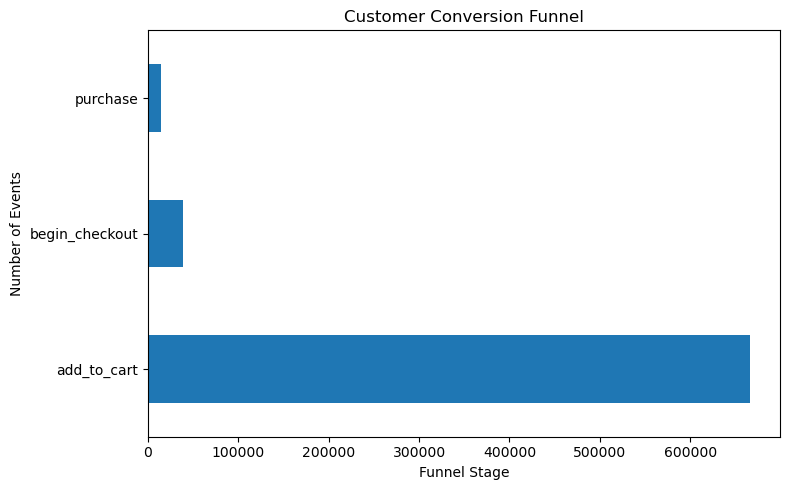

In [48]:
plt.figure(figsize=(8,5))

funnel_data.plot(kind="barh")

plt.title("Customer Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Events")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

#### Create Funnel KPI Table

In [52]:
funnel_kpis = pd.DataFrame({
    "KPI": [
        "Cart to Checkout Rate",
        "Checkout to Purchase Rate",
        "Overall Conversion Rate"
    ],
    "Value (%)": [
        5.80,
        38.11,
        2.21
    ]
})

funnel_kpis

,KPI,Value (%)
0,Cart to Checkout Rate,5.80
1,Checkout to Purchase Rate,38.11
2,Overall Conversion Rate,2.21


A significant drop-off occurs between the add-to-Cart and begin_checkout stages. Only 5.8% of cart events progress to checkout, resulting in an overall conversion rate of 2.21%. This indicates that the primary conversion bottleneck exists before the checkout process.

## Device Analysis

#### Create Device Data

In [53]:
device_conversion = pd.DataFrame({
    "Device": ["Mobile", "Desktop", "Tablet"],
    "Conversion Rate (%)": [2.24, 2.20, 1.84]
})

device_conversion

,Device,Conversion Rate (%)
0,Mobile,2.24
1,Desktop,2.20
2,Tablet,1.84


#### Visualize Device Performance

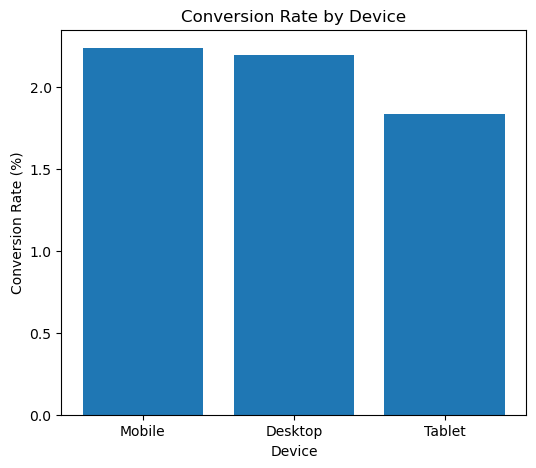

In [55]:

plt.figure(figsize=(6,5))

plt.bar(
    device_conversion["Device"],
    device_conversion["Conversion Rate (%)"]
)

plt.title("Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate (%)")

plt.show()

Mobile recorded the highest conversion rate, slightly outperforming desktop users. Tablet users showed the lowest conversion rate, suggesting a higher likelihood of abandoning the purchase journey.

#### Checkout Rate by Data

In [56]:
device_checkout = pd.DataFrame({
    "Device": ["Desktop", "Mobile", "Tablet"],
    "Checkout Rate (%)": [5.87, 5.72, 5.19]
})

device_checkout

,Device,Checkout Rate (%)
0,Desktop,5.87
1,Mobile,5.72
2,Tablet,5.19


#### Checkout Rate by Chart

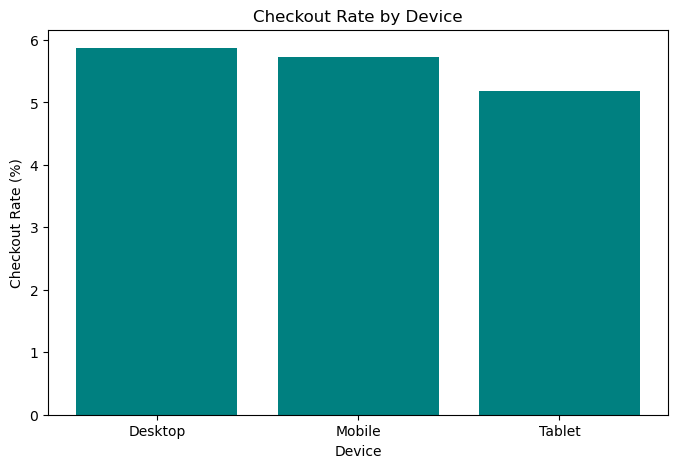

In [64]:
plt.figure(figsize=(8,5))

plt.bar(
    device_checkout["Device"],
    device_checkout["Checkout Rate (%)"],
    color = 'teal'
)

plt.title("Checkout Rate by Device")
plt.xlabel("Device")
plt.ylabel("Checkout Rate (%)")

plt.show()

Desktop recorded the highest checkout rate, with mobile users performing almost as well. Tablet users showed the lowest checkout rate, suggesting they are less likely to move from cart to checkout. Overall checkout performance is fairly similar across devices, although tablet users may face slightly more friction in the shopping journey.

## Country Analysis

#### Create Country Data

In [58]:
country_purchases = pd.DataFrame({
    "Country": ["US","IN","CA","GB","ES","FR","CN","DE","JP","TW"],
    "Purchases": [6506,1343,1308,442,347,309,248,238,220,215]
})

country_purchases

,Country,Purchases
0,US,6506
1,IN,1343
2,CA,1308
3,GB,442
4,ES,347
5,FR,309
6,CN,248
7,DE,238
8,JP,220
9,TW,215


#### Visualize Country's Purchase Chart

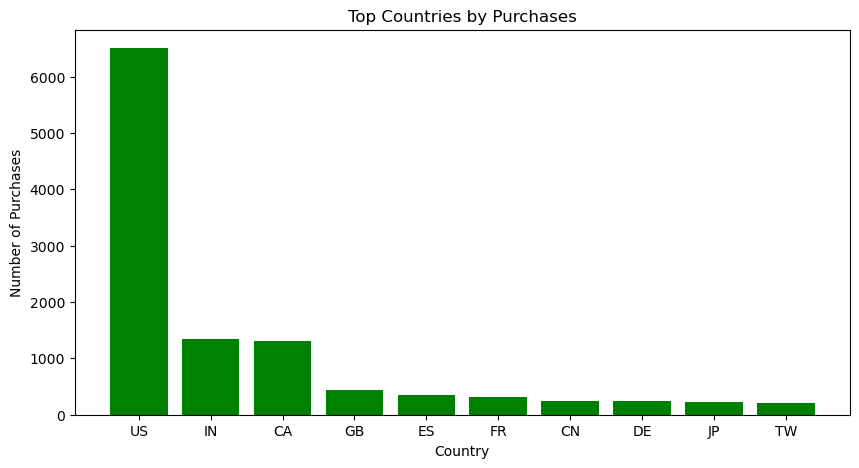

In [63]:
plt.figure(figsize=(10,5))

plt.bar(
    country_purchases["Country"],
    country_purchases["Purchases"],
    color="green"
)

plt.title("Top Countries by Purchases")
plt.xlabel("Country")
plt.ylabel("Number of Purchases")

plt.show()

The United States generated the highest number of purchases by a significant margin, followed by India and Canada. This indicates that customer purchases are heavily concentrated in a few key markets, while the remaining countries contribute a much smaller share of total transactions.

## Product Categories Analysis 

#### Create Category Data

In [65]:
category_purchases = pd.DataFrame({
    "Category": [
        "Apparel","Campus Collection","New","Accessories",
        "Shop by Brand","Office","Drinkware",
        "Bags","Clearance","Lifestyle"
    ],
    "Purchases": [
        4858,1456,1397,1173,818,
        798,680,671,633,583
    ]
})

category_purchases

,Category,Purchases
0,Apparel,4858
1,Campus Collection,1456
2,New,1397
3,Accessories,1173
4,Shop by Brand,818
5,Office,798
6,Drinkware,680
7,Bags,671
8,Clearance,633
9,Lifestyle,583


#### Visualize Performance by Product Category

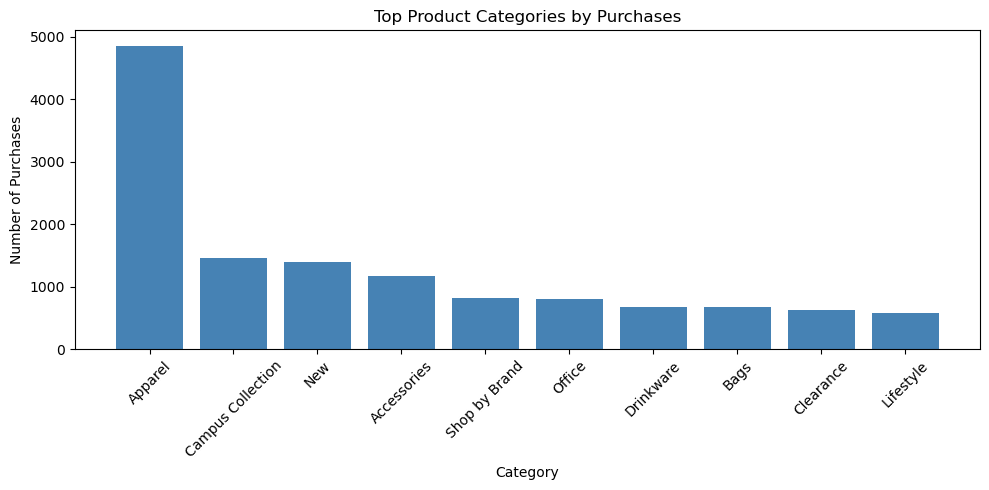

In [67]:
plt.figure(figsize=(10,5))

plt.bar(
    category_purchases["Category"],
    category_purchases["Purchases"],
    color="steelblue"
)

plt.title("Top Product Categories by Purchases")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Apparel was the most purchased product category by a large margin, significantly outperforming all other categories. Campus Collection and New products were the next most popular categories, indicating that customer demand is concentrated in a few key product groups.

#### Revenue by Product Category

##### Create Revenue by data

In [68]:
category_revenue = pd.DataFrame({
    "Category": [
        "Apparel","Bags","New","Campus Collection",
        "Shop by Brand","Accessories","Drinkware",
        "Uncategorized Items","Lifestyle","Clearance"
    ],
    "Revenue": [
        157235,19137,18506,15553,
        15049,13810,10505,
        10354,10031,8605
    ]
})

category_revenue

,Category,Revenue
0,Apparel,157235
1,Bags,19137
2,New,18506
3,Campus Collection,15553
4,Shop by Brand,15049
5,Accessories,13810
6,Drinkware,10505
7,Uncategorized Items,10354
8,Lifestyle,10031
9,Clearance,8605


##### Visualize Performance by Revenue

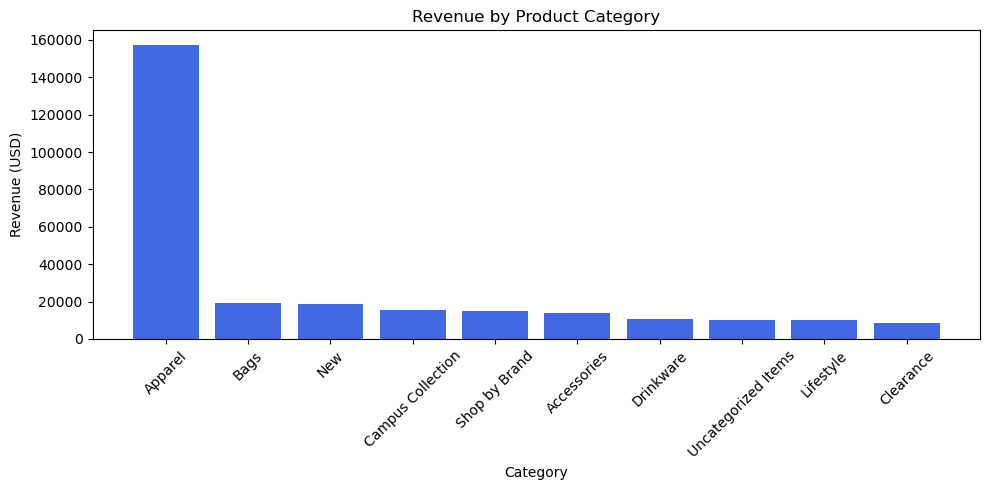

In [76]:
plt.figure(figsize=(10,5))

plt.bar(
    category_revenue["Category"],
    category_revenue["Revenue"],
    color="royalblue"
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Apparel generated the highest revenue by a significant margin, contributing far more than any other category. While categories such as Bags, New, and Campus Collection generated moderate revenue, the results indicate that Apparel is the primary revenue driver for the business.

#### Conversion Rate by Category

#### Create Category Conversion Data

In [77]:
category_conversion = pd.DataFrame({
    "Category": [
        "Small Goods","Gift Cards","Google","Stationery",
        "Writing Instruments","Campus Collection",
        "Fun","Office","Drinkware","Eco-Friendly"
    ],
    "Conversion Rate (%)": [
        7.37,6.88,5.09,4.75,
        4.09,3.57,
        3.54,3.42,3.08,3.06
    ]
})

category_conversion

,Category,Conversion Rate (%)
0,Small Goods,7.37
1,Gift Cards,6.88
2,Google,5.09
3,Stationery,4.75
4,Writing Instruments,4.09
5,Campus Collection,3.57
6,Fun,3.54
7,Office,3.42
8,Drinkware,3.08
9,Eco-Friendly,3.06


#### Visualize Performance by Category Conversion Chart

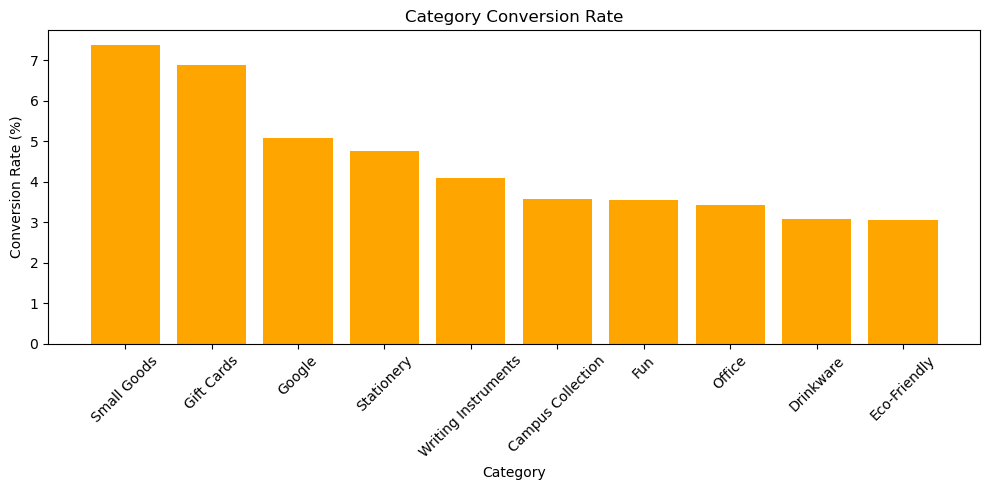

In [78]:
plt.figure(figsize=(10,5))

plt.bar(
    category_conversion["Category"],
    category_conversion["Conversion Rate (%)"],
    color="orange"
)

plt.title("Category Conversion Rate")
plt.xlabel("Category")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Small Goods and Gift Cards recorded the highest conversion rates, indicating stronger purchase intent among customers interested in these categories. In contrast, categories with lower conversion rates may require further investigation to understand potential barriers to purchase.

## Customer Value Analysis (LTV)

#### Create Customer Segment Data

In [79]:
ltv_segments = pd.DataFrame({
    "Segment": ["Low Value", "Medium Value", "High Value"],
    "Customers": [268993, 1093, 68]
})

ltv_segments

,Segment,Customers
0,Low Value,268993
1,Medium Value,1093
2,High Value,68


The customer base is heavily concentrated in the Low Value segment, while only a small proportion of customers fall into the Medium and High Value segments. This highlights an opportunity to increase customer lifetime value through stronger retention and repeat purchase strategies.